In [94]:
# 기본 경로 설정

import os

ROOT_DIR = os.getcwd()
IS_COLAB_MODE = False

# 코랩 모드
if ROOT_DIR == "/content":

    IS_COLAB_MODE = True
    project_num = 13

    from google.colab import drive
    import subprocess

    drive.mount('/content/drive')


    print("[[ colab ]]")

    if "raw.tar.gz" not in os.listdir():
        url = f"https://github.com/wonbywondev/ML-DL/releases/download/data-v{project_num}/raw.tar.gz"
        subprocess.run(["wget", url], check=True)

    print("· 압축 파일 있음")


    DATA_DIR = os.path.join(ROOT_DIR, "data")
    RAW_DIR = os.path.join(DATA_DIR, "raw")

    if not os.path.exists(DATA_DIR):
        os.mkdir(DATA_DIR)

    if not os.path.exists(RAW_DIR):
        subprocess.run(["tar", "-xzvf", "raw.tar.gz", "-C", DATA_DIR], check=True)

    print("· data 압축 해제 완료")


# 로컬 모드
else:
    print("[[ local ]]")
    ROOT_DIR = "/".join(ROOT_DIR.split("/")[:-1])
    DATA_DIR = os.path.join(ROOT_DIR, "data")
    RAW_DIR = os.path.join(DATA_DIR, "raw")

[[ local ]]


In [95]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import gc


# 시각화 관련 설정
if not IS_COLAB_MODE:
    import matplotlib.font_manager as fm
    try:
        plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
    except:
        try:
            plt.rcParams['font.family'] = 'NanumGothic'
        except:
            plt.rcParams['font.family'] = 'AppleGothic'

    plt.rcParams['axes.unicode_minus'] = False
    fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)

In [96]:
from pathlib import Path

raw_json_path_list = [str(path) for path in Path(RAW_DIR).rglob("*.json")]

if IS_COLAB_MODE:
    import unicodedata
    raw_json_path_list = [unicodedata.normalize("NFC", path) for path in raw_json_path_list]

len(raw_json_path_list)

2026

In [97]:
import random
import json

rand_idx = random.randint(1, len(raw_json_path_list))
rand_path = raw_json_path_list[rand_idx - 1]

with open(rand_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

rand_idx = random.randint(1, len(sample))
sample[rand_idx - 1]

{'Index': '663521',
 'RawText': '전에는 향기가 나는 체리향이나 딸기향을 함유한 상품을 사용하다가 향에 대한 거부감과 색소가 있는 듯 해서 이 상품을 시도해봤는데요. 기존 사용하던 상품이랑 별 차이가 없네요. 고유의 향이 있는데 제가 안좋아하는 향이에요. 무향이라고 해서 샀는데 무향이 아니라 아쉽네요.',
 'Source': '쇼핑몰',
 'Domain': '화장품',
 'MainCategory': '메이크업/뷰티소품',
 'ProductName': 'OO 맨** 케어 4.8g 1개',
 'ReviewScore': '5',
 'Syllable': '150',
 'Word': '36',
 'RDate': '20201111',
 'GeneralPolarity': '-1',
 'Aspects': [{'Aspect': '향',
   'SentimentText': '고유의 향이 있는데 제가 안좋아하는 향이에요. ',
   'SentimentWord': '6',
   'SentimentPolarity': '-1'},
  {'Aspect': '향',
   'SentimentText': '무향이라고 해서 샀는데 무향이 아니라 아쉽네요. ',
   'SentimentWord': '6',
   'SentimentPolarity': '-1'}]}

In [98]:
import json
import pandas as pd

column_list = ["RawText", "Word", "GeneralPolarity"]
all_data = []

for path in raw_json_path_list:
    with open(path, "r", encoding="utf-8") as f:
        dict_list = json.load(f)
        
        for item in dict_list:
            filtered_item = {key: item.get(key) for key in column_list}
            
            all_data.append(filtered_item)

filtered_df = pd.DataFrame(all_data, columns=column_list)

print(f"· 총 데이터: {len(filtered_df)}개")

· 총 데이터: 201616개


In [99]:
print("[결측치]")

for column in column_list:
    if sum(filtered_df[column].isna()) > 0:
        print(f"· 결측 항목: {column}")
        print(f"· {sum(filtered_df[column].isna())}개")
        print(f"· 예시: \n{filtered_df[filtered_df[column].isna()].head(5)}")

        filtered_df = filtered_df.dropna()
        print(f"\n· 제거 후 데이터: {len(filtered_df)}개")

filtered_df["GeneralPolarity"] = filtered_df["GeneralPolarity"].astype(int)

[결측치]
· 결측 항목: GeneralPolarity
· 17091개
· 예시: 
                                              RawText Word GeneralPolarity
13  귀에서 자꾸 빠져요.귀에 꼽는재 질이 미끄러운 재질이라 작은 소품이지만 재질만 바꾸...   89            None
43  아이를 출산한 기념으로 TV를 바꿨습니다. 그전에 쓰던 TV가 꽤나 무거워서 떨어지...   79            None
44  화면에 노이즈가 생깁니다. 저희 가족 중에 아무도 TV 화면을 건드리거나 하지 않았...   85            None
55  이번에 이사하면서 우리 따님께서 방에 TV가 있으면 좋겠다고 하여, 방에서 사용할 ...   73            None
93  기존에 사용하던 무선이어폰이 오래되어서 배터리가 광탈하는 바람에 새로운 상품이 필요...   68            None

· 제거 후 데이터: 184525개


In [100]:
print("[중복치]")

if sum(filtered_df["RawText"].duplicated()) > 0:
    print(filtered_df[filtered_df["RawText"].duplicated()].head(5))

else:
    print("중복치 없음")

[중복치]
중복치 없음


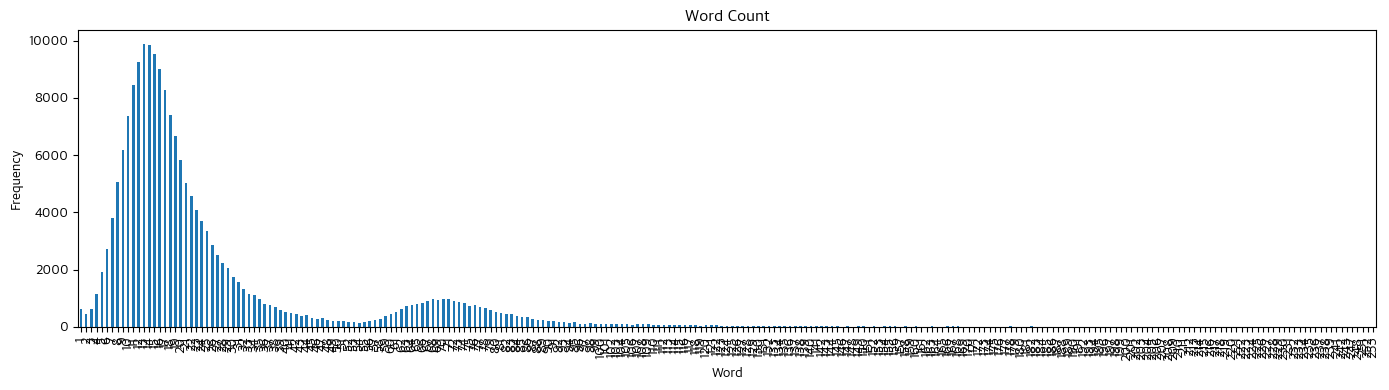

In [101]:
filtered_df["Word"] = filtered_df["Word"].astype(int)

data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

In [102]:
print("[극단치]")

filtered_df = filtered_df[filtered_df["Word"] <= 50]

print(f"· 제거 후 데이터: {len(filtered_df)}개")

[극단치]
· 제거 후 데이터: 158825개


In [107]:
filtered_df = filtered_df.reset_index().drop("index", axis=1)

In [110]:
SIMPLE_DICT = filtered_df.to_dict("index")

SIMPLE_DICT

{0: {'RawText': '기대이상으로 마음에 들어서 좋습니다 저는 주방전용으로 라디오기능만 사용하고 있는데  ㅋㅋ하루 중 제일 오래 머무르는 주방에서 듣다보니 퇴근 무렵 라디오 교통 방송으로 20대 때 어느 날도 문득 생각나네요~  이것 저것 만지는 게 어려워서 한 다이얼만 고정해서 한 채널만 듣고 있구요~그래도 좋아요^^ 다만 디자인이 좀 촌스러운 느낌이라 아쉬워요 ㅠ',
  'Word': 47,
  'GeneralPolarity': 0},
 1: {'RawText': '프로젝터와 스크린 사이 간격이 넓지않아도 영상을 보는데 아무런 지장이 없어서 마음에 들어요  게다가 화질이 좋아서 문자나 영상볼때 실감나고 아주 좋아요 다만 스피커가 소리확장성이 떨어져 별로네요',
  'Word': 25,
  'GeneralPolarity': 0},
 2: {'RawText': '노이즈가 들리질 않고 깨끗하게 잘들려요 좋아요... 지난번에 구매했던 마이크는 노이즈가 엄청 많이 들려서 아쉬웠네요.... 이번에는 노래방에서 쓰는 것과 비슷한 퀄리티라 아주 만족스러운 편이에요! 하울링도 많이 퍼지지 않아서 집에서 사용하기 딱 맞아서 좋습니다. 외형이 화려하고 예쁘서 마음에 들고 친구들이랑 놀 때도 들고 나갈 정도로 간편하고 실용적이네요^^',
  'Word': 45,
  'GeneralPolarity': 1},
 3: {'RawText': '나만의 라이프 스타일에 딱 맞는 TV로 사용하려고 구매했는데 무선 연결이 잘 안되다보니 멀티뷰로 화면을 분할해서 동시에 보는 것은 물론  다양하게 TV를 활용할 수 없고 네트워킹이 안돼서 업무도 볼 수가 없네요ㅠㅠ 화질도 흐릿해서 색감표현이 약한 부분이 있어서 짜증나네요. 사운드도 뭉개지는 소리가 나와서 정말 실망스럽네요.',
  'Word': 43,
  'GeneralPolarity': -1},
 4: {'RawText': '우리집에서 사용중인 주방세제 소개할게요. OOO입니다. 며칠전 다시 재구매했길래 리뷰 남겨봅니다.  자주 이용하

In [88]:
# 텔레그램

import requests
from dotenv import load_dotenv
import os


def send_telegram_message(message):
    load_dotenv()
    
    token = os.getenv("TELEGRAM_BOT_TOKEN")
    chat_id = os.getenv("TELEGRAM_CHAT_ID")

    url = f'https://api.telegram.org/bot{token}/sendMessage'
    payload = {
        'chat_id': chat_id,
        'text': message
        }
    
    try:
        requests.post(url, json=payload)
    except Exception as e:
        print(f"Failed to send message: {e}")

# 모델 학습 코드 끝에 추가

message = ""

send_telegram_message(message)